In [1]:
import argparse
import json
import collections
import random
import pandas as pd  
import os  
# criteria
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
from eval_metrics.evaluate_metrics import calculate_exactmatch, calculate_f1score
from rouge import Rouge
from pycocoevalcap.cider.cider import Cider

from tabulate import tabulate
from eval_metrics.glossary import *
from tqdm import tqdm
import os
# from openpyxl import Workbook
# from PIL import Image
from run_eval_utils import (
    extract_answers,
    cut_words,
    load_jsonl,
    confusion_mat

)
from multiclass_metrics import multiclass_metrics


/root/userfolder/anaconda3/envs/llava/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import warnings
warnings.simplefilter('ignore')

In [3]:
ifd_dict = {
    0: "未见明显异常。",
    1: "眼底白斑。",
    2: "早产儿视网膜病变(ROP)。",
    3: "眼底出血。"
}

cls2label = {
    "未见明显异常。": 0,
    "视网膜出血。": 1,
    "早产儿视网膜病变。": 2,
    "白斑。": 3
}

In [4]:
extract_answers("<think>颞侧周边网膜可见灰白色、纤细、平坦分界线，线前为无血管区，线后血管稍迂曲。</think> <answer>早产儿视网膜病变。</answer>.")

{'description': '颞侧周边网膜可见灰白色、纤细、平坦分界线，线前为无血管区，线后血管稍迂曲。', 'answer': '早产儿视网膜病变。'}

In [5]:

def evaluate_with_cot(pred_list, r=4):
    """
    Evaluate predictions using various metrics, including BLEU, F1, Rouge, and Cider.

    Parameters:
        pred_list (list): List of dictionaries containing ground truth and predicted responses.

    Returns:
        dict: A dictionary containing open and closed metrics.
    """
    
    # Initialize evaluators and storage
    rouge_evaluator = Rouge()
    cider_evaluator = Cider(n=4, sigma=6)
    cider_data = {"ground_truths": {}, "predictions": {}}
    metrics = collections.defaultdict(list)
    closed_counters = collections.defaultdict(int)
    # 统计每个样本的类别
    labels = collections.defaultdict(list)
    ids = []
    for prediction in tqdm(pred_list, desc="Processing Predictions"):
        try:
            sample_id, gt_resp, pred_resp = prediction['sample_id'], prediction["gt_response"], prediction["pred_response"]
        except:
            sample_id, gt_resp, pred_resp = prediction['question_id'], prediction['ground_truth'], prediction['text']
        if sample_id in ids:
            continue
        else:
            ids.append(sample_id)

        # print(gt_resp)
        gt_patterns = extract_answers(gt_resp)
        pred_patterns = extract_answers(pred_resp)

        gt_desc, gt_label = gt_patterns['description'], gt_patterns['answer'] 
        pred_desc, pred_label = pred_patterns['description'], pred_patterns['answer']        
        
        labels["gt"].append(cls2label[gt_label])
        labels["pred"].append(cls2label[pred_label])

        # Open hit score
        metrics['open_hit'].append(1.0 if gt_desc in pred_desc else 0.0)

        # Tokenization and normalization
        tokenized_gt, tokenized_pred = cut_words(gt_desc), cut_words(pred_desc)
        norm_gt, norm_pred = normalize_word(" ".join(tokenized_gt)), normalize_word(" ".join(tokenized_pred))

        # word-level acc
        f1, precision, recall = calculate_f1score(norm_pred, norm_gt)
        metrics['f1'].append(f1)
        metrics['precision'].append(precision)
        metrics['recall'].append(recall)
        metrics['exact_match'].append(calculate_exactmatch(norm_pred, norm_gt))
        
        # BLEU
        bleu_scores = []
        for i, weights in enumerate([(1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0), (0, 0, 0, 1)]):
            bleu = sentence_bleu([tokenized_gt], tokenized_pred, weights)
            metrics[f'bleu_{i+1}'].append(bleu)
            bleu_scores.append(bleu)
        metrics['bleu_avg'].append(sum(bleu_scores) / len(bleu_scores))

        # ROUGE-1 and ROUGE-2
        for v in ['p', 'r', 'f']:
            rouges = rouge_evaluator.get_scores(norm_pred, norm_gt)[0]
            rouge1 = rouges['rouge-1'][v]
            rouge2 = rouges['rouge-2'][v]
            metrics[f'rouge_{v}'].append((rouge1 + rouge2)/2)

        # METEOR
        metrics['meteor'].append(meteor_score([tokenized_gt], tokenized_pred))
        
        # Cider
        cider_data["ground_truths"][sample_id] = [norm_gt]
        cider_data["predictions"][sample_id] = [norm_pred]

    # Aggregate metrics
    open_metrics = {key: round(sum(values) / len(values), r) for key, values in metrics.items() if values}
    cider_score = cider_evaluator.compute_score(
        cider_data["ground_truths"], 
        cider_data['predictions'])[0]
    open_metrics.update({'cider': round(cider_score / 10, r)})

    TP, FP, FN, TN = closed_counters['TP'], closed_counters['FP'], closed_counters['FN'], closed_counters['TN']
    total = TP + FP + FN + TN
    closed_metrics = {
        # 'tp_ratio': round(TP / total, r) if total > 0 else 0.0,
        # 'fp_ratio': round(FP / total, r) if total > 0 else 0.0,
        # 'fn_ratio': round(FN / total, r) if total > 0 else 0.0,
        # 'tn_ratio': round(TN / total, r) if total > 0 else 0.0,
        'accuracy': round((TP + TN) / total, r) if total > 0 else 0.0,
        'specificity': round(TN / (TN + FP), r) if (TN + FP) > 0 else 0.0,
        'precision': round(TP / (TP + FP), r) if (TP + FP) > 0 else 0.0,
        'recall': round(TP / (TP + FN), r) if (TP + FN) > 0 else 0.0,
        'f1': round(2 * TP / (2 * TP + FP + FN), r) if (2 * TP + FP + FN) > 0 else 0.0
    }
    print(labels['pred'])
    print(labels['gt'])
    confusion_mat(labels['pred'], labels['gt'])
    precisions, recalls, specificitys, f1_scores, result = multiclass_metrics(labels['pred'], labels['gt'])
    class_metrics = {
        "mc_precision": round(precisions/100, r),
        "mc_recall": round(recalls/100, r),
        "mc_specificitys": round(specificitys/100, r),
        "mc_f1": round(f1_scores/100, r),
        "AUC": round(result/100, r)
    }
    print("Valid num after remove duplication:", len(ids))

    return {'open': open_metrics, 'closed': closed_metrics, 'class': class_metrics}


In [6]:
# 评估一个文件，输入文件名即可
def eval_item_with_cot(pred_file, is_print=False):
    """
    模型性能评估
    在模型性能评估中，分为两方面：
    1. 开放集：指将模型的输出内容作为完全开放的任务进行评估，主要是以词语为单位；
    2. 闭合集：指将模型的输出内容作为二分类任务进行评估（即眼底图像是否含有异常）。
    3. 多分类：指将模型的输出按照关键词提取得到对三种疾病+正常眼底的分类情况，最终指标是类别平均（macro）
    指标包括：
    * **开放集：** 单词完全匹配(exact match), BLUE(1~4), precision, recall, F1(词语级别), rouge, cider, 开放命中率；
    * **闭合集：** 准确率（正误正确率），precision, recall, F1, speci
    """    
    name = pred_file.split("/")[-2]
    pred = load_jsonl(pred_file)
    print(name)
    try:
        pred_ids = [item['question_id'] for item in pred]
    except:
        pred_ids = [item['sample_id'] for item in pred]
    num_pred_ids = len(pred_ids)
    print(f'num_pred_ids: {num_pred_ids}')

    # Perform evaluation
    metrics = evaluate_with_cot(pred)
    # metrics['info'] = extract_checkpoint_info(name)
    metrics['info'] = {
        "version": name
    }
    if name.endswith("ftmlp"):
        metrics['info']['MLP'] = 1
        metrics['info']['LLM'] = 0
    if name.endswith("ftmlpllm"):
        metrics['info']['MLP'] = 1
        metrics['info']['LLM'] = 1
    # open_num = metrics['open_num']

    # print(f'num_pred_ids: {num_pred_ids} || valid_open_num: {open_num}')

    if is_print:
        open_met = tabulate(
                metrics['open'].items(),
                headers=['Metric', 'Performance']
            )
        print(open_met)
        print('-'*24)
        closed_met = tabulate(
                metrics['closed'].items(),
                headers=['Metric', 'Performance']
            )
        print(closed_met)
        print('-'*24)
        class_met = tabulate(
                metrics['class'].items(),
                headers=['Metric', 'Performance']
            )
        print(class_met)
    
    sep_str = "="*len(name)
    print(sep_str)

    return metrics  

## 1. 分析指定的文件
将文件列表放到一个列表中生成对应的表格数据

llava-onevision-qwen2-7b-si-ft-lora-1epoch-NFD-freeze_backbone_valid_1gpu
num_pred_ids: 1034


Processing Predictions:   0%|          | 0/1034 [00:00<?, ?it/s]

Processing Predictions: 100%|██████████| 1034/1034 [00:01<00:00, 779.39it/s]


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 

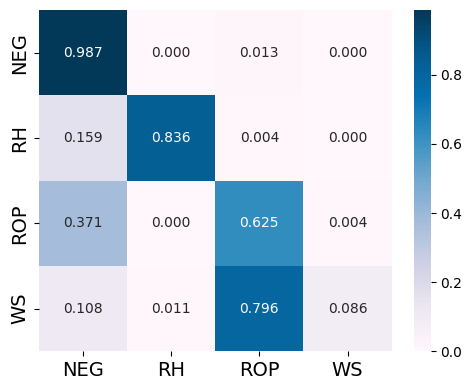

Valid num after remove duplication: 1034
llava-onevision-qwen2-7b-si-ft-lora-3epoch-NFD-freeze_backbone_valid_1gpu
num_pred_ids: 1034


Processing Predictions: 100%|██████████| 1034/1034 [00:01<00:00, 699.34it/s]


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 3, 0, 2, 2, 3, 2, 0, 0, 

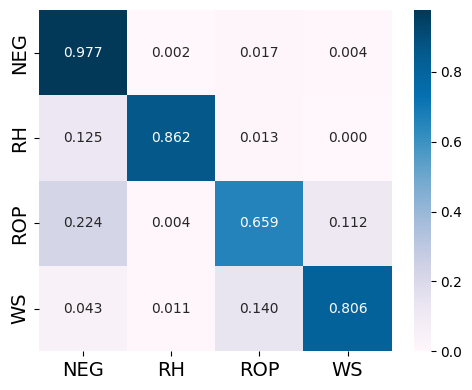

Valid num after remove duplication: 1034
llava-onevision-qwen2-7b-si-ft-lora-3epoch-NFD-freeze_backbone_valid_3
num_pred_ids: 1034


Processing Predictions: 100%|██████████| 1034/1034 [00:01<00:00, 708.36it/s]


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 2, 0, 2, 2, 3, 2, 0, 0, 

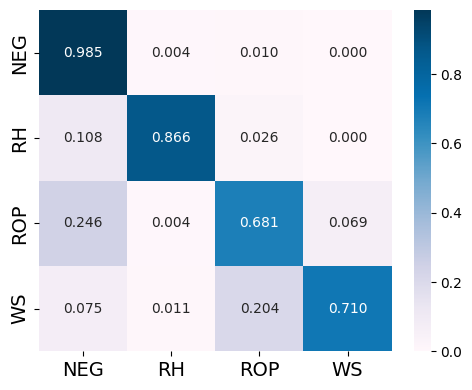

Valid num after remove duplication: 1034


In [8]:
pred_dir = "/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/llava/results"
pred_list = sorted(list(os.listdir(pred_dir)))
pred_files = [os.path.join(pred_dir, file, 'IFD_answers.jsonl') for file in pred_list]


open_metrics = pd.DataFrame()
closed_metrics = pd.DataFrame()
class_metrics = pd.DataFrame()

for pred_file in pred_files:
    # print(pred_file)
    metrics = eval_item_with_cot(pred_file, is_print=False)
    open_met = metrics['open']
    closed_met = metrics['closed']
    class_met = metrics['class']
    open_metrics = pd.concat([open_metrics, pd.DataFrame([open_met])], ignore_index=True)
    closed_metrics = pd.concat([closed_metrics, pd.DataFrame([closed_met])], ignore_index=True)
    class_metrics = pd.concat([class_metrics, pd.DataFrame([class_met])], ignore_index=True)
    

In [9]:
open_metrics

,open_hit,f1,precision,recall,exact_match,bleu_1,bleu_2,bleu_3,bleu_4,bleu_avg,rouge_p,rouge_r,rouge_f,meteor,cider
0,0.5309,0.7822,0.8292,0.7635,0.8068,0.7115,0.6580,0.6366,0.6194,0.6564,0.7726,0.7198,0.7360,0.7167,0.5880
1,0.5377,0.8308,0.8551,0.8266,0.8158,0.7701,0.7129,0.6887,0.6688,0.7101,0.8039,0.7807,0.7846,0.7792,0.6292
2,0.5435,0.8306,0.8579,0.8240,0.8211,0.7711,0.7155,0.6909,0.6710,0.7121,0.8077,0.7794,0.7858,0.7789,0.6323


In [10]:
class_metrics

,mc_precision,mc_recall,mc_specificitys,mc_f1,AUC
0,0.8263,0.6337,0.9145,0.6425,0.7741
1,0.8559,0.8262,0.9460,0.8349,0.8861
2,0.8666,0.8106,0.9452,0.8335,0.8779


: 